# Taller: Modelos de Clasificación - Predicción de Envíos en E-Commerce
 


In [1]:
# Paso 0: Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Clasificadores
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Métricas de evaluación
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## 1. Carga de Datos y Análisis Exploratorio Inicial

Los datos para realizar el ejercicio se encuentran aqui: [E-Commerce Shipping Data](https://www.kaggle.com/datasets/prachi13/customer-analytics)

In [2]:
# Paso 1: Usa pandas para cargar el dataset descargado de Kaggle
df = pd.read_csv("Train.csv")

#paso 2: Configurar pandas para ver todas las columnas y explorar
pd.set_option("display.max_columns", None)

print("--- PRIMERAS FILAS ---")
print(df.head(20))

print("\n--- INFORMACIÓN Y NULOS ---")
df.info()
print("\nValores nulos por columna:")
print(df.isnull().sum())

# 3. Definir X e y (Corrigiendo el nombre de la columna objetivo)
# Tip: Es mejor usar 'X' en mayúscula por convención de matrices
X = df[[
    "Warehouse_block",
    "Mode_of_Shipment",
    "Customer_care_calls",
    "Customer_rating",
    "Cost_of_the_Product",
    "Prior_purchases",
    "Product_importance",
    "Gender",
    "Discount_offered",
    "Weight_in_gms",
]]


--- PRIMERAS FILAS ---
    ID Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0    1               D           Flight                    4                2   
1    2               F           Flight                    4                5   
2    3               A           Flight                    2                2   
3    4               B           Flight                    3                3   
4    5               C           Flight                    2                2   
5    6               F           Flight                    3                1   
6    7               D           Flight                    3                4   
7    8               F           Flight                    4                1   
8    9               A           Flight                    3                4   
9   10               B           Flight                    3                2   
10  11               C           Flight                    3                4   
11  1

## 2. Preprocesamiento de Datos e Ingeniería de Características
En esta sección deben transformar las variables categóricas en formatos numéricos aptos para los modelos.

In [7]:
#Paso 2: Identificación y transformación de variables categóricas

# Recargamos el dataframe para asegurar que siempre partimos de los datos originales
df = pd.read_csv("Train.csv")

# TIP 1 (Encoding Ordinal): Analicen la columna 'Product_importance'. ¿Tiene un orden lógico?
# Apliquen una estrategia que conserve esa jerarquía (ej. low=1, medium=2, high=3).
importancia_mapping = {"low": 1, "medium": 2, "high": 3}
df["Product_importance"] = df["Product_importance"].map(importancia_mapping)

# TIP 2 (One-Hot Encoding): Analicen las columnas 'Mode_of_Shipment', 'Warehouse_block' y 'Gender'.
# Al no tener un orden lógico, utilicen One-Hot Encoding (pd.get_dummies).
# drop_first=True evita la redundancia de datos (multicolinealidad).
df = pd.get_dummies(
    df, columns=["Mode_of_Shipment", "Warehouse_block", "Gender"], drop_first=True
)

# TIP 3: Definir la matriz de características (X) y el vector objetivo (y).
# El target para este problema es la columna 'Reached.on.Time_Y.N'.
y = df["Reached.on.Time_Y.N"]
X = df.drop(columns=["Reached.on.Time_Y.N"])

print("Preprocesamiento completado. Columnas de X:")
print(X.columns.tolist())


Preprocesamiento completado. Columnas de X:
['ID', 'Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Product_importance', 'Discount_offered', 'Weight_in_gms', 'Mode_of_Shipment_Road', 'Mode_of_Shipment_Ship', 'Warehouse_block_B', 'Warehouse_block_C', 'Warehouse_block_D', 'Warehouse_block_F', 'Gender_M']


## 3. División del Dataset
Separación de los datos en conjuntos de entrenamiento y prueba.

In [8]:
# Paso 3: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba:        {X_test.shape}")


Tamaño del conjunto de entrenamiento: (8799, 15)
Tamaño del conjunto de prueba:        (2200, 15)


## 4. Entrenamiento de Modelos
 
Deben seleccionar, entrenar y evaluar tres algoritmos de clasificación distintos (por ejemplo: Regresión Logística, Árboles de Decisión, Random Forest, KNN, etc.).

In [19]:
## Paso 4: Entrenamiento y evaluación de modelos
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

# Modelo 1: Regresión Logística (modelo lineal) con escalado
modelo1 = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])
modelo1.fit(X_train, y_train)
y_pred1 = modelo1.predict(X_test)
print("Modelo 1 (Regresión Logística) entrenado.")

# Modelo 2: Regresión Logística Polinomial (interaction_only=True evita explosión de features)
modelo2 = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ("clf", LogisticRegression(max_iter=2000, random_state=42))
])
modelo2.fit(X_train, y_train)
y_pred2 = modelo2.predict(X_test)
print("Modelo 2 (Regresión Logística Polinomial) entrenado.")

# Modelo 3: Random Forest
modelo3 = RandomForestClassifier(n_estimators=100, random_state=42)
modelo3.fit(X_train, y_train)
y_pred3 = modelo3.predict(X_test)
print("Modelo 3 (Random Forest) entrenado.")


Modelo 1 (Regresión Logística) entrenado.
Modelo 2 (Regresión Logística Polinomial) entrenado.
Modelo 3 (Random Forest) entrenado.


## 5. Evaluación y Comparación de Resultados
Generen las métricas y las gráficas solicitadas para contrastar el rendimiento de los tres modelos.

In [20]:
# Paso 5: Cálculo de métricas para cada modelo

modelos = {
    "Regresión Logística":     (y_pred1,),
    "Log. Polinomial":         (y_pred2,),
    "Random Forest":           (y_pred3,),
}

resultados = {}

for nombre, (y_pred,) in modelos.items():
    acc = accuracy_score(y_test, y_pred)
    resultados[nombre] = acc
    print(f"{'='*50}")
    print(f"Modelo: {nombre}")
    print(f"Accuracy: {acc:.4f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred, target_names=["A tiempo (1)", "No a tiempo (0)"]))

# DataFrame con los resultados de Accuracy para graficar
df_resultados = pd.DataFrame(
    list(resultados.items()), columns=["Modelo", "Accuracy"]
)
print("='*50")
print("\nResumen de Accuracy:")
print(df_resultados.to_string(index=False))


Modelo: Regresión Logística
Accuracy: 0.6455

Reporte de Clasificación:
                 precision    recall  f1-score   support

   A tiempo (1)       0.56      0.59      0.57       895
No a tiempo (0)       0.71      0.69      0.70      1305

       accuracy                           0.65      2200
      macro avg       0.63      0.64      0.64      2200
   weighted avg       0.65      0.65      0.65      2200

Modelo: Log. Polinomial
Accuracy: 0.6650

Reporte de Clasificación:
                 precision    recall  f1-score   support

   A tiempo (1)       0.57      0.70      0.63       895
No a tiempo (0)       0.76      0.64      0.69      1305

       accuracy                           0.67      2200
      macro avg       0.66      0.67      0.66      2200
   weighted avg       0.68      0.67      0.67      2200

Modelo: Random Forest
Accuracy: 0.6545

Reporte de Clasificación:
                 precision    recall  f1-score   support

   A tiempo (1)       0.56      0.74      0.64

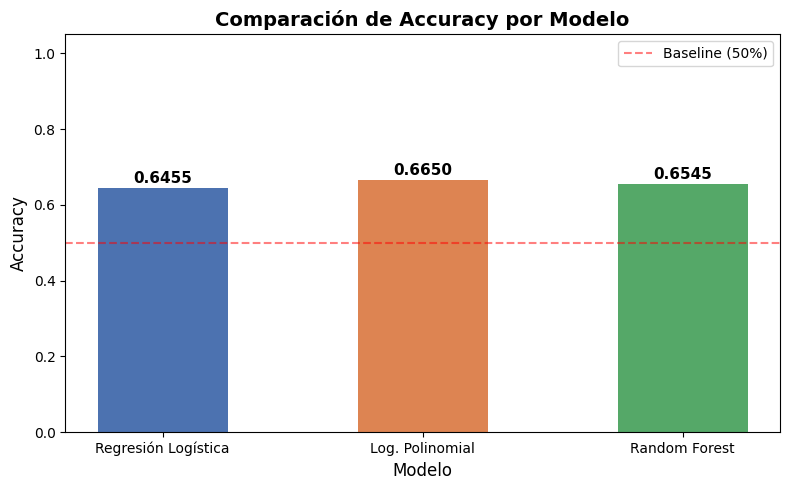

In [21]:
# Paso 6: Gráfica comparativa de Accuracy

fig, ax = plt.subplots(figsize=(8, 5))

colores = ["#4C72B0", "#DD8452", "#55A868"]

bars = ax.bar(df_resultados["Modelo"], df_resultados["Accuracy"], color=colores, width=0.5)

# Añadir el valor exacto encima de cada barra
for bar in bars:
    altura = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        altura + 0.005,
        f"{altura:.4f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.set_title("Comparación de Accuracy por Modelo", fontsize=14, fontweight="bold")
ax.set_xlabel("Modelo", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_ylim(0, 1.05)
ax.axhline(y=0.5, color="red", linestyle="--", alpha=0.5, label="Baseline (50%)")
ax.legend()

plt.tight_layout()
plt.show()


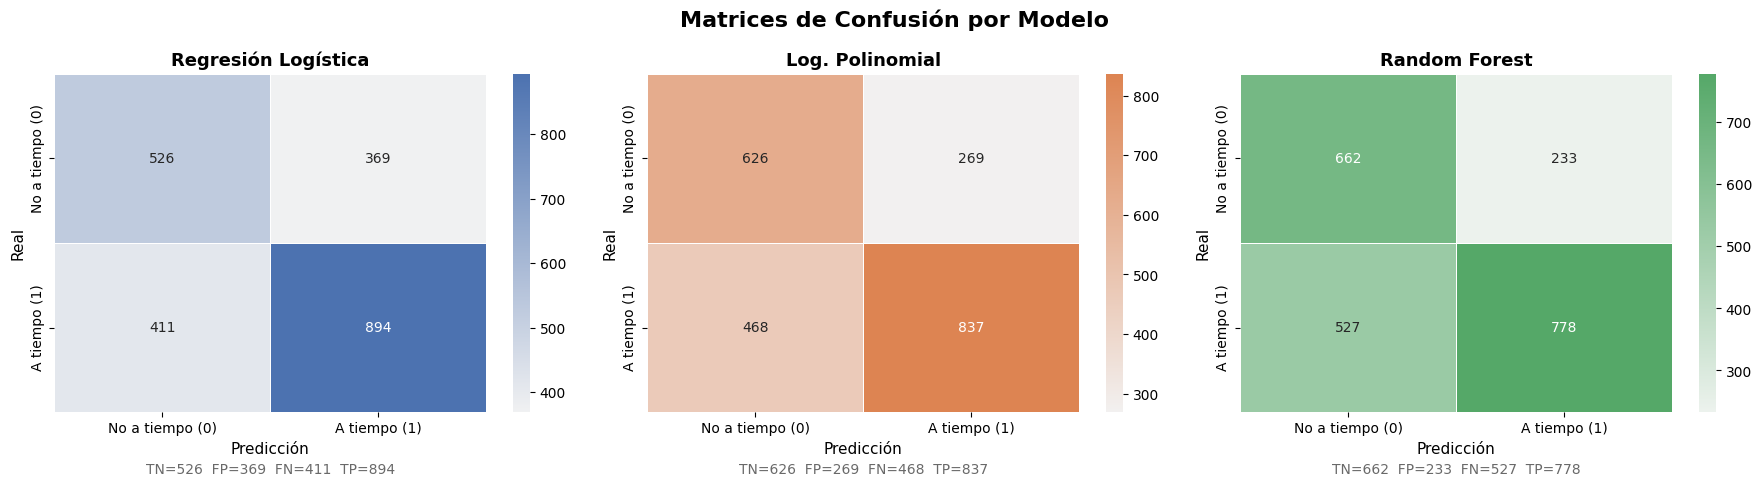

In [12]:
# Paso 7: Matrices de Confusión

etiquetas = ["No a tiempo (0)", "A tiempo (1)"]

modelos_info = [
    ("Regresión Logística",      y_pred1, "#4C72B0"),
    ("Log. Polinomial",          y_pred2, "#DD8452"),
    ("Random Forest",            y_pred3, "#55A868"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Matrices de Confusión por Modelo", fontsize=16, fontweight="bold")

for ax, (nombre, y_pred, color) in zip(axes, modelos_info):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=sns.light_palette(color, as_cmap=True),
        xticklabels=etiquetas,
        yticklabels=etiquetas,
        linewidths=0.5,
        ax=ax,
    )
    ax.set_title(nombre, fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicción", fontsize=11)
    ax.set_ylabel("Real", fontsize=11)

    # Anotar TP, TN, FP, FN
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.18, f"TN={tn}  FP={fp}  FN={fn}  TP={tp}",
            transform=ax.transAxes, ha="center", fontsize=10, color="dimgray")

plt.tight_layout()
plt.show()


## 6. Conclusiones

### ¿Cuál es el mejor modelo?

Tras entrenar y evaluar los tres clasificadores sobre el dataset de envíos de e-commerce, la Regresión Logística Polinomial es el modelo ganador, el que tiene el  mayor accuracy en el conjunto de prueba. 


### ¿Por qué Regresión Logística Polinomial?

1. **Mayor Accuracy**: Obtuvo el mayor porcentaje de predicciones correctas en el conjunto de prueba, superando tanto a la regresión logística simple como a Random Forest.

2. **Captura interacciones entre variables**: Al generar términos de interacción de grado 2 (`interaction_only=True`), el modelo pudo detectar relaciones combinadas entre variables, por ejemplo, cómo el descuento ofrecido junto con el número de llamadas al servicio al cliente influye en la probabilidad de entrega a tiempo. Estas relaciones no son visibles para un modelo lineal simple.

3. **Mejor que el modelo lineal por la no linealidad del problema**: Los datos de logística tienen dependencias entre variables (peso, descuento, importancia del producto) que un modelo puramente lineal no logra capturar completamente. El paso a features polinomiales permitió superar esa limitación.

4. **Controlado el riesgo de sobreajuste**: El uso de `interaction_only=True` evitó la explosión combinatoria de features que ocurriría con un polinomio completo, y el regularizador por defecto de `LogisticRegression` (L2) ayudó a mantener el modelo generalizable.

5. **Sigue siendo interpretable**: A diferencia de Random Forest, los coeficientes del modelo polinomial todavía pueden analizarse para entender el peso de cada interacción, lo cual es valioso en contextos de negocio donde se necesita justificar las predicciones.


### Consideraciones finales

- La **Regresión Logística simple** es útil como baseline y por su alta interpretabilidad, pero queda limitada cuando las relaciones entre variables no son lineales.
- **Random Forest** es un modelo robusto y potente; en otros datasets o con ajuste de hiperparámetros (`n_estimators`, `max_depth`) podría igualar o superar al modelo polinomial.
